# Generic Tutorial for CoPhaser
This notbook should provide a generic tutorial for the use of CoPhaser. 

If you want to see in detail how the different results presented in the paper were obtained you can have a look at the ``paper/`` folder, which contains all the code to generate the result and replicate the figures from the results.

A major advantage of CoPhaser is that it can work with any cycle across any contexts and sequencing technologies and has low computational requirement (on a GPU you can train it in a couple a minute for a dataset of 50,000 cells with ~300 mo of RAM, and 1h for 2 milion of cells but requires more RAM). However, the hyperparameter tuning can be tricky depending on the signal to noise ratio of the cycle (and the inference can be impossible if the data quality is too low). Furthermore, I would advise to test the stability of the results by training from scratch different models if the cycle seems noisy.

Running this notebook (13000 cells) should take ~ 2 minutes if you have access to a gpu, and ~4 minutes if the training is performed on the CPU. On the CPU of a laptop the execution time should be ~10 minutes.

## Package and Environment Set-Up
0) Download this repo
1) Create a [conda environment](https://www.anaconda.com/docs/getting-started/miniconda/main)
```bash
conda create -n "CoPhaser_Env" python=3.13
conda activate CoPhaser_Env
```
2) Install PyTorch with CUDA support (if you want to use the GPU)
   **Note:** Check your CUDA driver version (`nvidia-smi`) and install the compatible PyTorch version. 
   Go to [the official page](https://pytorch.org/) for more information. The code was tested using the version 2.9.1.
   
   To dowload CUDA 12.6, for instance, with the latest PyTorch version:
```bash
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
```
3) Install the package
```bash
cd CoPhaser/
pip install .
```

You should now be able to use an environment called ``CoPhaser_env`` containing all the required packages.

## Data Processing

CoPhaser works directly with the raw counts, and it does not require the separation of the spliced and unspliced counts. A basic filtering, with the removal of data of low quality should be performed prior to the model training. As an example, I will use a dataset of RPE1 cells containing 2 batches. I advise the interested reader to first generate the dataset using the notbook ``0_generate_rp1_dataset.iypnb``, since creating the dataset should not take too long. (Most of the running time depends on your internet connection speed, to download the 300 mb dataset).

In [202]:
import numpy as np
import os
from CoPhaser import utils
from CoPhaser.trainer import Trainer
from CoPhaser.loss import Loss
from CoPhaser import plotting
from CoPhaser.model import CoPhaser
from CoPhaser import gene_sets

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from importlib import resources

import anndata
import scanpy as sc

import pandas as pd

In [203]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [204]:
DATA_FOLDER = "data"
adata = sc.read_h5ad(os.path.join(DATA_FOLDER, "rpe1_velocycle.h5ad"))
adata

AnnData object with n_obs × n_vars = 14259 × 36591
    obs: 'batch', 'n_counts', 'n_genes'
    obsm: 'X_pca', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [205]:
# quality control: filter out cells with less than 200 genes and genes expressed in less than 3 cells.
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

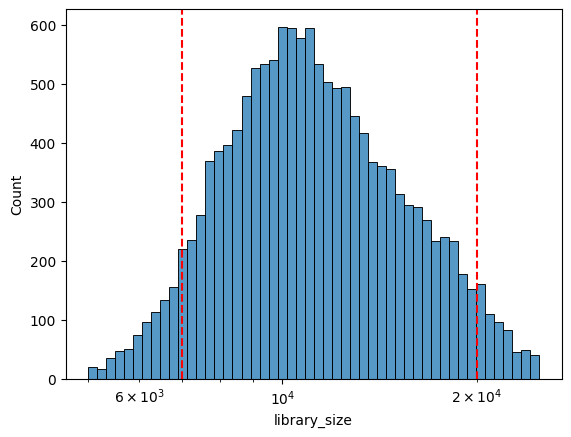

In [206]:
# filter outliars based on the library size (total counts per cell)
adata.obs["library_size"] = adata.layers["spliced"].sum(axis=1).A1
sns.histplot(adata.obs["library_size"], bins=50, log_scale=True)
min_counts = 7000
max_counts = 20000
plt.axvline(min_counts, color="red", linestyle="--")
plt.axvline(max_counts, color="red", linestyle="--")

In [207]:
adata = adata[
    (adata.obs["library_size"] >= min_counts)
    & (adata.obs["library_size"] <= max_counts)
]
adata

View of AnnData object with n_obs × n_vars = 12843 × 19349
    obs: 'batch', 'n_counts', 'n_genes', 'library_size'
    var: 'n_cells'
    obsm: 'X_pca', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

## CoPhaser Fitting

We will first define the rhythmic gene sets - genes known to display rhythmic patterns with respect to the cell cycle.

In [208]:
SMALL_CYCLING_GENE_SET = gene_sets.SMALL_CELL_CYCLE_GENE_SET
SMALL_CYCLING_GENE_SET = [
    gene.upper() for gene in SMALL_CYCLING_GENE_SET if gene.upper() in adata.var_names
]
print(f"Number of genes in the small cycling gene set: {len(SMALL_CYCLING_GENE_SET)}")

Number of genes in the small cycling gene set: 98


We will then define the context genes - genes providing enough information to assign cells to different biological contexts. Here and most of the time we just use the 2000 most variable genes.

In [209]:
context_genes = utils.get_variable_genes(adata)

Epoch 1/200, elbo_loss: 1402.9520, kl_div_f: 4.6802, kl_div_z: 10.7382, fraction_cycling_cells: 1.0000, l2_px_rate: 0.0000, entropy_loss_unweighted: -2.5998, entropy_loss: -519.9527, radial_variance: 12.1714, radius: 27.1144, L1_mu_z: 0.0000, MI_loss: 0.0000, total_loss: 922.2852
Epoch 2/200, elbo_loss: 1075.7477, kl_div_f: 4.6282, kl_div_z: 8.0695, fraction_cycling_cells: 1.0000, l2_px_rate: 0.0000, entropy_loss_unweighted: -3.2934, entropy_loss: -658.6876, radial_variance: 2.3318, radius: 2.5693, L1_mu_z: 0.0000, MI_loss: 0.0001, total_loss: 421.9689
Epoch 3/200, elbo_loss: 1046.2671, kl_div_f: 4.5666, kl_div_z: 8.2524, fraction_cycling_cells: 1.0000, l2_px_rate: 0.0000, entropy_loss_unweighted: -3.3641, entropy_loss: -672.8112, radial_variance: 2.2571, radius: 2.4958, L1_mu_z: 0.0000, MI_loss: 0.0010, total_loss: 378.3657
Epoch 4/200, elbo_loss: 1025.3568, kl_div_f: 4.5021, kl_div_z: 8.2773, fraction_cycling_cells: 1.0000, l2_px_rate: 0.0000, entropy_loss_unweighted: -3.3795, entrop

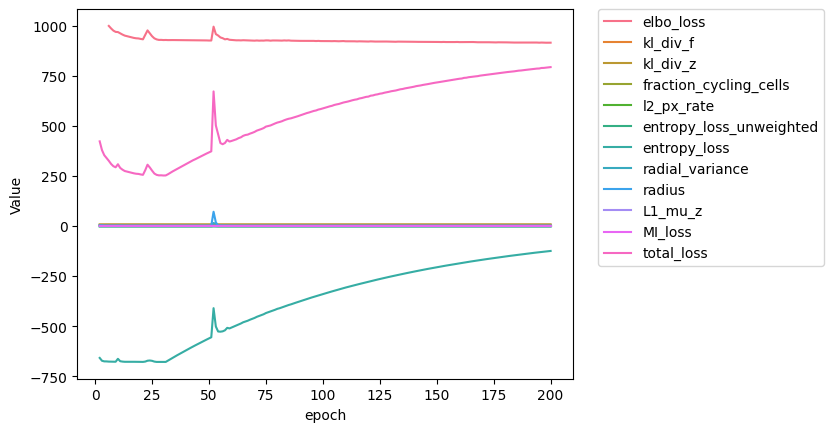

In [210]:
model = CoPhaser(
    SMALL_CYCLING_GENE_SET,
    context_genes=context_genes,
    n_latent=2,
)
model.load_anndata(adata, layer_to_use="spliced")
trainer = Trainer(
    model,
    Loss.compute_loss,
    noise_model="NB",
    closed_circle_weight=10,
    MI_weight=150,
    entropy_weight_factor=200,
    MI_detach="f",
    rhythmic_likelihood_weight=1,
)
trainer.train_model(
    n_epochs=200,
    lr=1e-2,
    batch_size=1024,
)

<Axes: ylabel='Count'>

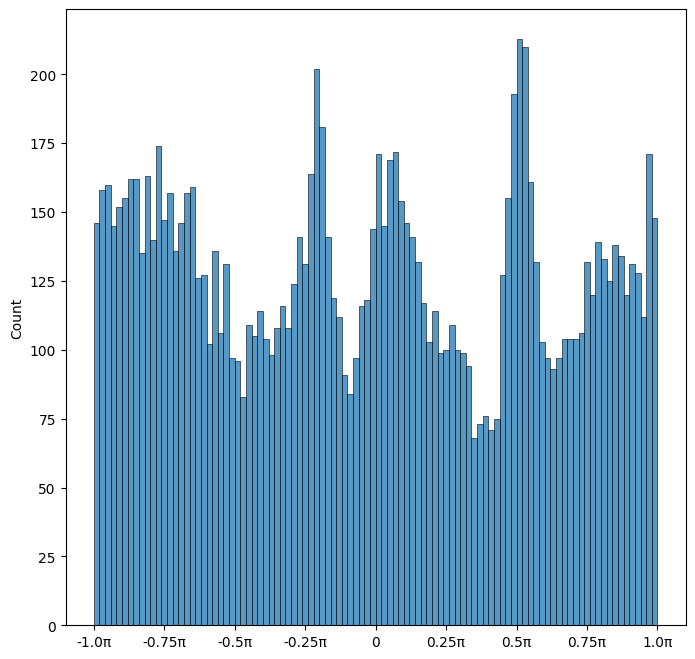

In [211]:
# Get the infered theta values
model.to("cpu")
generative_outputs, space_outputs = model.get_outputs()
thetas = space_outputs["theta"]
plotting.modify_axis_labels()
sns.histplot(thetas, bins=100)

While not essential, since it depends on the noise of the cycle and your ```closed_circle_weight``` value, the projected space is most frequently shaped as a cycle.

<Axes: >

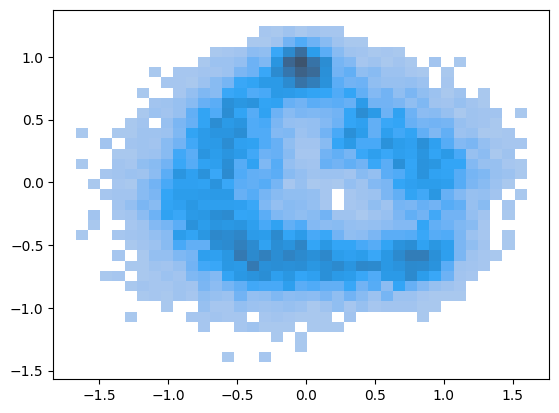

In [212]:
cells_projected = space_outputs["x_projected"].detach().numpy()
sns.histplot(x=cells_projected[:, 0], y=cells_projected[:, 1])

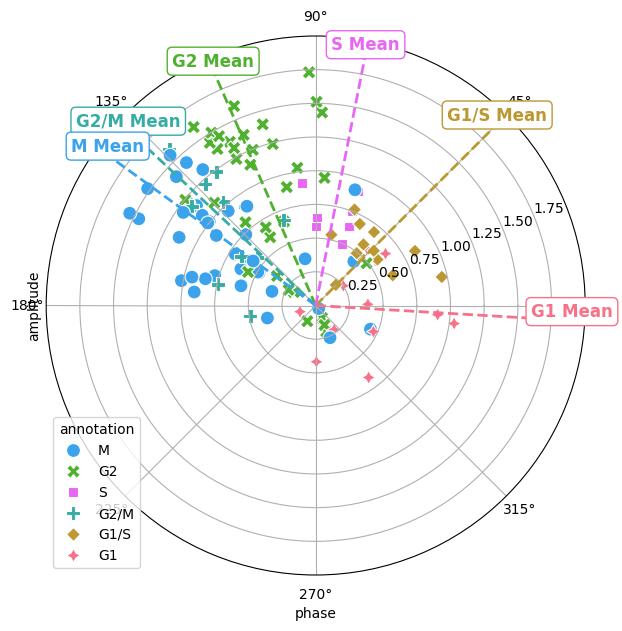

In [213]:
# for the cell cycle we can automatically allign the phases such as g1/S is at 1/4pi and the direction follows the cell cycle
thetas = model.orient_align_pseudotimes(
    space_outputs["theta"],
    offset=1 / 4 * np.pi,
)

In [214]:
def add_theta(df, theta):
    df["inferred_theta"] = theta
    return df


df_mean = pd.DataFrame(
    generative_outputs["px_rate"].detach().numpy(), columns=model.context_genes
)
df_mean = add_theta(df_mean, thetas)
# df_rhythmic = pd.DataFrame(generative_outputs["rhythmic_term"].detach().numpy(), columns=model.rhythmic_gene_names)
df_rhythmic = pd.DataFrame(
    generative_outputs["F"].detach().numpy(), columns=model.context_genes
)
df_rhythmic = add_theta(df_rhythmic, thetas)
df_z = pd.DataFrame(
    generative_outputs["Z"].detach().numpy(), columns=model.context_genes
)
df_z = add_theta(df_z, thetas)

You should always ensure that the cycle captured correspond to your biological cycle. Here we present some quality check, such as gene profiles, peaking phase ordering, #UMI per cell and histones peak for the cell cycle. Your plot should be similar to these. If they are not this mean that the training of the model did not converged towards the expected biological cycle, and retraining the model from scratch is required. This can happen due to the random initialization of the model, and can be mitigated by providing prior knowledge on the fourier coefficients instead of random intialization.

/home/maxine/Documents/paychere/CoPhaser/src/CoPhaser/plotting.py:551: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend(loc="upper left", bbox_to_anchor=(1, 1))


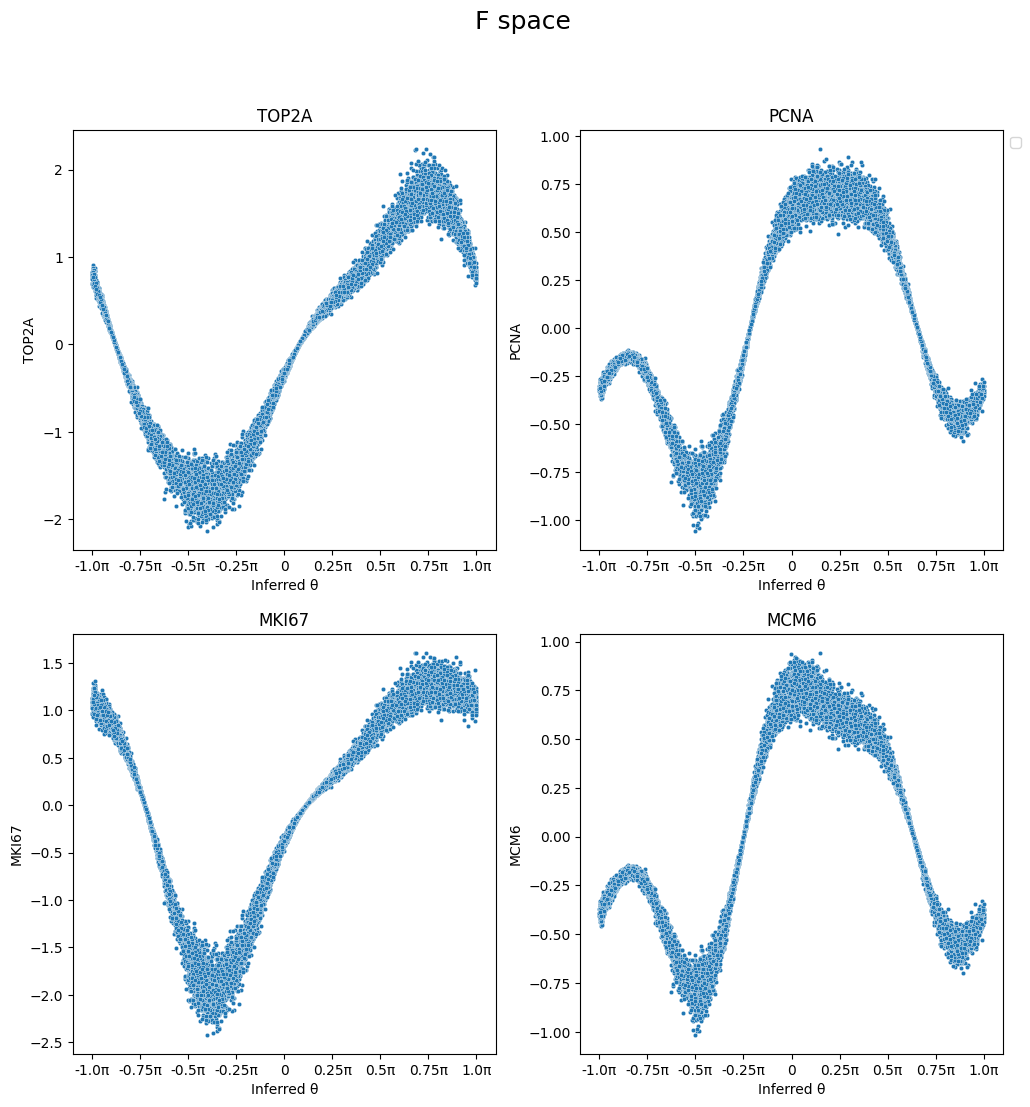

In [215]:
plotting.plot_model_decoded_space(df_rhythmic, gene_to_upper=True, title="F space")

/home/maxine/Documents/paychere/CoPhaser/src/CoPhaser/plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


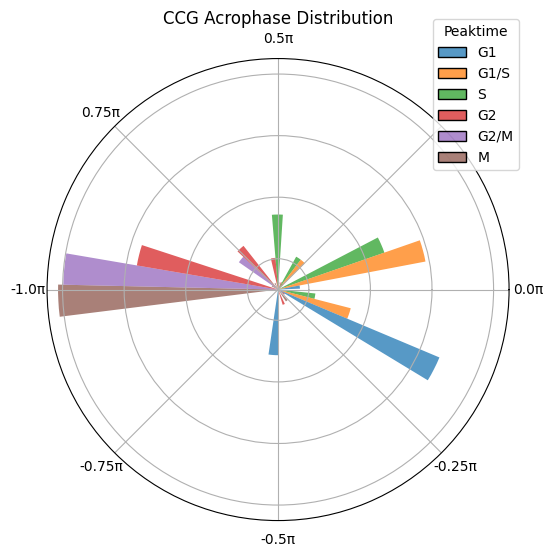

In [216]:
plotting.plot_cell_cycle(df_rhythmic)

/home/maxine/Documents/paychere/CoPhaser/src/CoPhaser/utils.py:32: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["histones_fraction"] = (


44 histone genes found in data


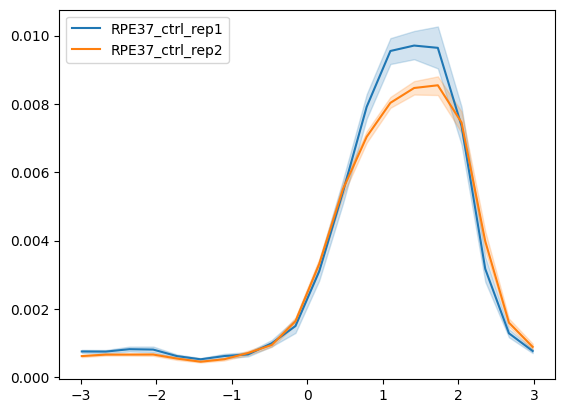

In [217]:
utils.add_histones_fraction(adata=adata, layer="spliced", use_only_clustered=True)
plotting.plot_smoothed_profiles(
    thetas.detach().numpy(),
    adata.obs["histones_fraction"],
    ax=plt.gca(),
    hue=adata.obs["batch"].values,
)

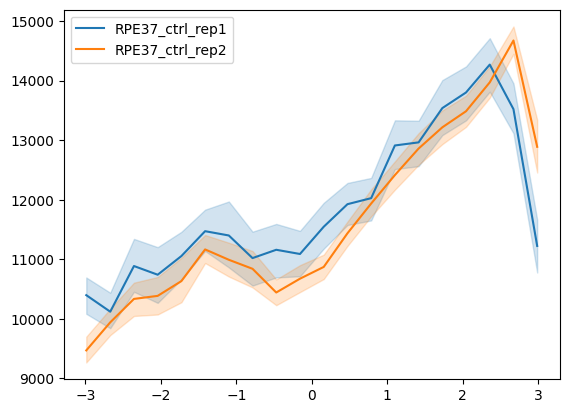

In [218]:
plotting.plot_smoothed_profiles(
    thetas.detach().numpy(),
    adata.obs["library_size"],
    ax=plt.gca(),
    hue=adata.obs["batch"].values,
)

## Explore context space

We can see that the two dimensional context space that we used can separate the two batches

Text(0.5, 1.0, 'Context space colored by batch')

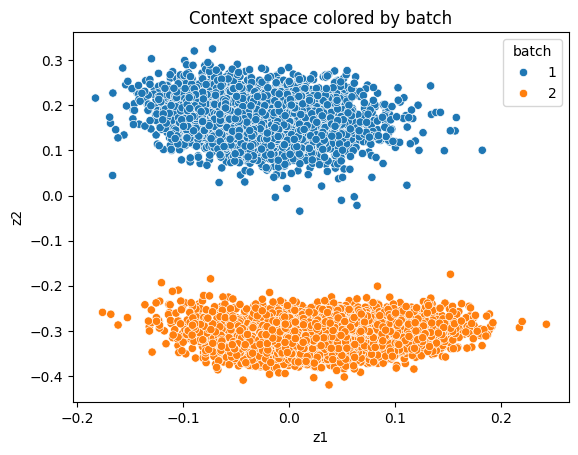

In [219]:
context = space_outputs["z"].detach().numpy()
sns.scatterplot(x=context[:, 0], y=context[:, 1], hue=adata.obs["batch"].str[-1:])
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Context space colored by batch")

We can see that the two dimensional context space contains no clear cell cycle phase information

Text(0.5, 1.0, 'Context space colored by batch')

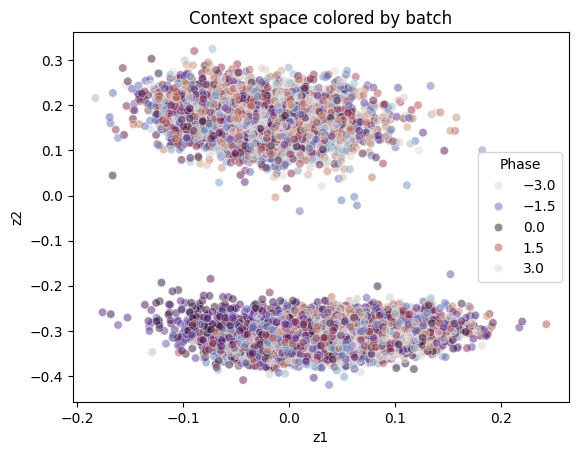

In [220]:
sns.scatterplot(
    x=context[:, 0],
    y=context[:, 1],
    hue=pd.Series(thetas, name="Phase"),
    alpha=0.5,
    palette="twilight",
)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Context space colored by batch")